
# DL Assignment 03

**Name:** _Mashrur Safir_

**Course Email:**  _shabab.ahmed2000sa@gmail.com_


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Import Libraries

In [354]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:


In [355]:
# Datasets
!git clone https://github.com/tajuar-akash-hub/Datasets.git

fatal: destination path 'Datasets' already exists and is not an empty directory.


In [356]:
# Loading the dataset
df = pd.read_csv('/content/Datasets/diabetes_two.csv')
df

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40.0,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58.0,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,NaN,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45.0,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,600.0,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39.0,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48.0,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58.0,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32.0,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


In [357]:
# checking if the dataset matches the requirements
df['class'].nunique()
# class is the target column here which only has two class.
# Binary classification checked

2

In [358]:
# checking if the dataset matches the requirements
df.shape[0]
# dataset contains 520 samples whereas requirement said that it should contain atleast 300 samples

520

In [359]:
# checking if the dataset matches the requirements
df.shape[1]
# requirement was to have atleast two input feature. This dataset has 17 such features.
# also, its csv

17

In [360]:
# Handling missing values
df.isnull().sum()
# it can be seen that the feature Age, Gender, weakness has one missing value respectively

,0
Age,1
Gender,1
Polyuria,0
Polydipsia,0
sudden weight loss,0
weakness,1
Polyphagia,0
Genital thrush,0
visual blurring,0
Itching,0


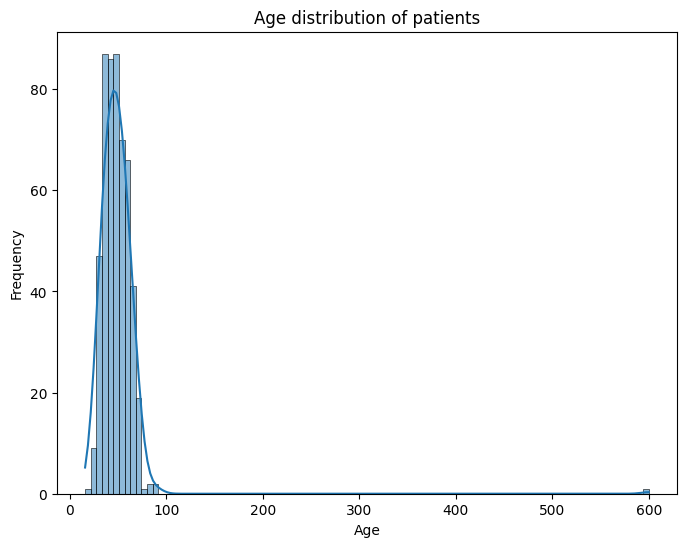

In [361]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], bins=100, kde=True)
plt.title("Age distribution of patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
# rightly skewed

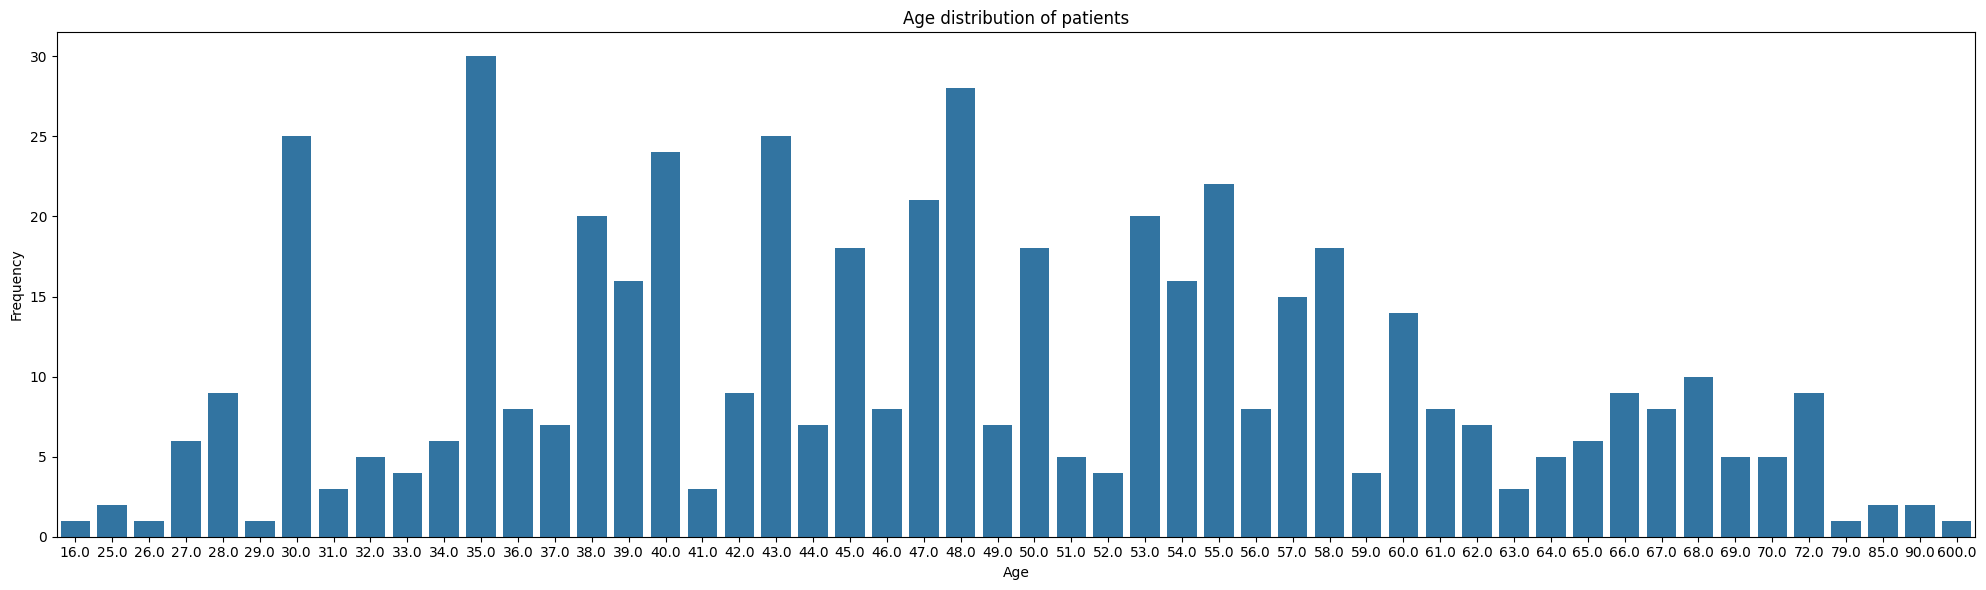

In [362]:
plt.figure(figsize=(20, 6))
sns.countplot(data=df, x='Age')
plt.title("Age distribution of patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
# there is an outlier -- 600

In [363]:
# Since the feature age is rightly skewed and has an outlier (600) we will be using median impute the missing value
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

In [364]:
# since gender and weakness has both categorical data, we will be using mode to impute their missing values
gender_mode = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna(gender_mode)

weakness_mode = df['weakness'].mode()[0]
df['weakness'] = df['weakness'].fillna(weakness_mode)

In [365]:
# after imputing, again confirming if there is any more missing values left within the data set
df.isnull().sum()

,0
Age,0
Gender,0
Polyuria,0
Polydipsia,0
sudden weight loss,0
weakness,0
Polyphagia,0
Genital thrush,0
visual blurring,0
Itching,0


In [366]:
# Encoding categorical variables
le = LabelEncoder()

# df['Alopecia'] = le.fit_transform(df['Alopecia'])
# df['Gender'] = le.fit_transform(df['Gender'])
# df['Genital thrush'] = le.fit_transform(df['Genital thrush'])
# df['Polyuria'] = le.fit_transform(df['Polyuria'])
# df['Polydipsia'] = le.fit_transform(df['Polydipsia'])
# df['sudden weight loss'] = le.fit_transform(df['sudden weight loss'])
# df['weakness'] = le.fit_transform(df['weakness'])
# df['Polyphagia'] = le.fit_transform(df['Polyphagia'])
# df['visual blurring'] = le.fit_transform(df['visual blurring'])
# df['Itching'] = le.fit_transform(df['Itching'])
# df['Irritability'] = le.fit_transform(df['Irritability'])
# df['delayed healing'] = le.fit_transform(df['delayed healing'])
# df['partial paresis'] = le.fit_transform(df['partial paresis'])
# df['muscle stiffness'] = le.fit_transform(df['muscle stiffness'])
# df['Obesity'] = le.fit_transform(df['Obesity'])
# df['class'] = le.fit_transform(df['class'])

for feature in df.columns:
  if feature == 'Age':
    continue
  df[feature] = le.fit_transform(df[feature])

# Here, label encoding was suitable because the categories were nominal

In [367]:
df

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40.0,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58.0,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,48.0,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45.0,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,600.0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39.0,0,1,1,1,0,1,0,0,1,0,1,1,0,0,0,1
516,48.0,0,1,1,1,1,1,0,0,1,1,1,1,0,0,0,1
517,58.0,0,1,1,1,1,1,0,1,0,0,0,1,1,0,1,1
518,32.0,0,0,0,0,1,0,0,1,1,0,1,0,0,1,0,0


In [368]:
# seperating features and target
X = df.drop(columns=['class'])  # Features
y = df['class']   # target

In [369]:
# splitting into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [370]:
# Feature Scaling
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
# Robust scaler is outlier resistant and it is easy to spot an outlier even after scaling since the outlier value is still high/low
# even after scaling
# scaling ensures that all the features are within a similar scale.

In [371]:
# converting to numpy
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [372]:
type(X_train)

numpy.ndarray

In [373]:
type(X_test)

numpy.ndarray

In [374]:
type(y_train)

numpy.ndarray

In [375]:
type(y_test)

numpy.ndarray

In [376]:
# converting to pytorch tensors
X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).float()
y_test = torch.from_numpy(y_test).float()
# converted to float32 to avoid any data type related error.

In [377]:
print(
    type(X_train),
    type(X_test),
    type(y_train),
    type(y_test)
)

<class 'torch.Tensor'> <class 'torch.Tensor'> <class 'torch.Tensor'> <class 'torch.Tensor'>


In [378]:
print(X_train.shape, y_train.shape)

torch.Size([416, 16]) torch.Size([416])


In [379]:
print(X_test.shape, y_test.shape)

torch.Size([104, 16]) torch.Size([104])


# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:


In [380]:
class Model(nn.Module):

  def __init__(self, num_features):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(num_features, 8),
        nn.ReLU(),
        nn.Linear(8, 1),
        nn.Sigmoid(),
    )

  def forward(self, features):
    out = self.network(features)
    return out

In [381]:
'''
There are a total of 16 features within the dataset. I chose to have 8 neurons within the hidden layer 1
because the input feature is 16 and so that it can learn non-linear
pattern as well as to make sure that the model does not overfit given the data set size is only 520 samples.

ReLU is used within the first hidden layer in order to introduce non-linearity and avert vanishing gradient problem which improves
the efficiency of the model.
On the other hand, sigmoid is used in the output layer as it outputs probabilites from 0-1. (which mathches with out dataset;
binary classification problem)
'''

'\nThere are a total of 16 features within the dataset. I chose to have 8 neurons within the hidden layer 1 so that it can learn non-linear\npattern as well as to make sure that the model does not overfit given the data set size is only 520 samples.\n\nReLU is used within the first hidden layer in order to introduce non-linearity and avert vanishing gradient problem which improves\nthe efficiency of the model.\nOn the other hand, sigmoid is used in the output layer as it outputs probabilites from 0-1. (which mathches with out dataset;\nbinary classification problem)\n'

In [382]:
model = Model(X_train.shape[1])

In [383]:
# Total number of trainable parameters
trainable_parameters = 0
for p in model.parameters():
  # print(p)
  if p.requires_grad:
    # print(p)
    # print(p.numel())
    trainable_parameters += p.numel()

print(trainable_parameters)

# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(total_params)

145


# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

In [384]:
loss_function = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

'''
This is a binary classification problem. From the ouput layer, we will receive probabilites either 0 or 1 since we have assignmed sigmoid function.
This will give probabilites based on default threshold. So, the loss function we used is binary cross entropy which fits with our type of
problem which we are trying to solve.
The dataset has two classes. As a result, the model will predict whether a sample belongs to either class 0 or 1. As far as BCE Loss is
concerned, it measures the difference between actual and predicted value implying a perfect fit from data set's nature as well.

Stocastic Gradient Descent (SGD) updates weights of the learnable parameters using gradient descent in order to minimise the loss
so that the model can improve in its prediction gradually. SGD works well with NN and medium sized data set which resembles the
data set we are using. learning rate of 0.1 is passed which controles how quickly or how much the weights are updated using each epoch.
SGD was sufficient for this data set and simple network.
'''

"\nThis is a binary classification problem. From the ouput layer, we will receive probabilites either 0 or 1 since we have assignmed sigmoid function. \nThis will give probabilites based on default threshold. So, the loss function we used is binary cross entropy which fits with our type of \nproblem which we are trying to solve. \nThe dataset has two classes. As a result, the model will predict whether a sample belongs to either class 0 or 1. As far as BCE Loss is \nconcerned, it measures the difference between actual and predicted value implying a perfect fit from data set's nature as well.\n\nStocastic Gradient Descent (SGD) updates weights of the learnable parameters using gradient descent in order to minimise the loss\nso that the model can improve in its prediction gradually. SGD works well with NN and medium sized data set which resembles the\ndata set we are using. learning rate of 0.1 is passed which controles how quickly or how much the weights are updated using each epoch.\n"

# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

In [385]:
train_loss_history = {}

for epoch in range(1, 101):

  # forward pass
  # X_train is passed into the forward method of the model class where prediction is calculated (y_pred = wx+b)
  y_pred = model(X_train)

  # Loss Computation
  # difference between the predicted values and actual values is calculated
  loss = loss_function(y_pred, y_train.reshape(-1, 1))

  # Gradient Reset
  # gradient is made zero to prevent gradient accumulation in each epoch
  optimizer.zero_grad()

  # Backward pass
  loss.backward()

  # Parameter update
  # weights and biases are updated with new values of weights and biases over a lr of 0.1
  optimizer.step()

  # storing every training loss history in dictionary
  train_loss_history["Epoch" + str(epoch)] = loss.item()

  # print loss
  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Loss: {loss.item()}")

Epoch: 10, Loss: 0.6517226696014404
Epoch: 20, Loss: 0.6231403946876526
Epoch: 30, Loss: 0.5883861780166626
Epoch: 40, Loss: 0.5478626489639282
Epoch: 50, Loss: 0.5055233836174011
Epoch: 60, Loss: 0.4632728397846222
Epoch: 70, Loss: 0.42220285534858704
Epoch: 80, Loss: 0.3846052289009094
Epoch: 90, Loss: 0.3521687388420105
Epoch: 100, Loss: 0.32455915212631226


In [386]:
# Training Loss History
print(train_loss_history)

{'Epoch1': 0.6746554970741272, 'Epoch2': 0.6723095774650574, 'Epoch3': 0.6699285507202148, 'Epoch4': 0.6674508452415466, 'Epoch5': 0.664972722530365, 'Epoch6': 0.6624435186386108, 'Epoch7': 0.6598759889602661, 'Epoch8': 0.6572831869125366, 'Epoch9': 0.6545515060424805, 'Epoch10': 0.6517226696014404, 'Epoch11': 0.6487820744514465, 'Epoch12': 0.6458413600921631, 'Epoch13': 0.6429224014282227, 'Epoch14': 0.6401633620262146, 'Epoch15': 0.6374813914299011, 'Epoch16': 0.6347534656524658, 'Epoch17': 0.6319741010665894, 'Epoch18': 0.6291368007659912, 'Epoch19': 0.6261952519416809, 'Epoch20': 0.6231403946876526, 'Epoch21': 0.6200441718101501, 'Epoch22': 0.6168879270553589, 'Epoch23': 0.613602876663208, 'Epoch24': 0.6102333664894104, 'Epoch25': 0.6067752242088318, 'Epoch26': 0.6032181978225708, 'Epoch27': 0.5996047854423523, 'Epoch28': 0.5959746241569519, 'Epoch29': 0.5922340750694275, 'Epoch30': 0.5883861780166626, 'Epoch31': 0.5844701528549194, 'Epoch32': 0.5805169343948364, 'Epoch33': 0.57652

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

In [387]:
with torch.no_grad():
  y_pred = model(X_train)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_train).float().mean()
  print(f"Accuracy using train set: {accuracy}")

Accuracy using train set: 0.5241655707359314


In [388]:
with torch.no_grad():
  y_pred = model(X_test)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_test).float().mean()
  print(f"Accuracy using test set: {accuracy}")

Accuracy using test set: 0.5808061957359314


In [389]:
'''
We say that,
The model is overfitting when it performs greatly on the training set but performs poorly on the test set.
The model is underfitting if it perfroms poorly on both trainig and test set.

Here, we can see that the accuracy score is low on both the training and test set, so it can be said that the model is underfitting
and is too simple to capture the complex pattern possed by the dataset
'''

'\nWe say that,\nThe model is overfitting when it performs greatly on the training set but performs poorly on the test set.\nThe model is underfitting if it perfroms poorly on both trainig and test set. \n\nHere, we can see that the accuracy score is low on both the training and test set, so it can be said that the model is underfitting\nand is too simple to capture the complex pattern possed by the dataset\n'

# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

In [398]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [399]:
train_loss_history = {}

for epoch in range(1, 1001):

  # forward pass
  # X_train is passed into the forward method of the model class where prediction is calculated (y_pred = wx+b)
  y_pred = model(X_train)

  # Loss Computation
  # difference between the predicted values and actual values is calculated
  loss = loss_function(y_pred, y_train.reshape(-1, 1))

  # Gradient Reset
  # gradient is made zero to prevent gradient accumulation in each epoch
  optimizer.zero_grad()

  # Backward pass
  loss.backward()

  # Parameter update
  # weights and biases are updated with new values of weights and biases over a lr of 0.1
  optimizer.step()

  # storing every training loss history in dictionary
  train_loss_history["Epoch" + str(epoch)] = loss.item()

  # print loss
  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Loss: {loss.item()}")

Epoch: 10, Loss: 0.17762194573879242
Epoch: 20, Loss: 0.17744725942611694
Epoch: 30, Loss: 0.1772739142179489
Epoch: 40, Loss: 0.17710183560848236
Epoch: 50, Loss: 0.17693108320236206
Epoch: 60, Loss: 0.176761656999588
Epoch: 70, Loss: 0.17659354209899902
Epoch: 80, Loss: 0.17642666399478912
Epoch: 90, Loss: 0.1762610524892807
Epoch: 100, Loss: 0.17609666287899017
Epoch: 110, Loss: 0.17593343555927277
Epoch: 120, Loss: 0.17577147483825684
Epoch: 130, Loss: 0.1756107211112976
Epoch: 140, Loss: 0.1754510998725891
Epoch: 150, Loss: 0.17529267072677612
Epoch: 160, Loss: 0.17513535916805267
Epoch: 170, Loss: 0.17497915029525757
Epoch: 180, Loss: 0.174824059009552
Epoch: 190, Loss: 0.17467008531093597
Epoch: 200, Loss: 0.17451715469360352
Epoch: 210, Loss: 0.17436529695987701
Epoch: 220, Loss: 0.17421451210975647
Epoch: 230, Loss: 0.1740647405385971
Epoch: 240, Loss: 0.1739160269498825
Epoch: 250, Loss: 0.1737682968378067
Epoch: 260, Loss: 0.17362158000469208
Epoch: 270, Loss: 0.173475831747

In [400]:
with torch.no_grad():
  y_pred = model(X_train)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_train).float().mean()
  print(f"Accuracy using train set: {accuracy}")

Accuracy using train set: 0.5151627063751221


In [401]:
with torch.no_grad():
  y_pred = model(X_test)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_test).float().mean()
  print(f"Accuracy using test set: {accuracy}")

Accuracy using test set: 0.5702662467956543


In [ ]:
'''
As far as convergence speed is concerned, it took few more seconds compared to the previous run.

Final performance largely remains unchanged with accuracy decreasing approximately by 0.01

Here, I decresed the learning rate to 0.01 from 0.1 and increased the number of epochs to 1000 from 100. This was a big jump.
But the results remain unsatisfactory implying that the model is too simple to capture the complex patters
and maybe we need to increase the number of hidden layers as well to see any dramatic changes.
'''

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:

In [ ]:
'''
We we call the method loss.backward() in pytorch, it calculates gradient. Lets say we are in epoch 1 and called this, it will
calculate gradient. Now, when we are in epoch 2, it will again calculate gradient but this time it will now only show
the gradint calculated in epoch 2 but it will accumulate the result with that of the previous epoch giving us an incorrect
value to update the model's learnable parameters. As a result, it is essential to call optimizer.zero_grad() so that the gradient is reset
before calculating the gradient of the current/new epoch. This will ensure that the parameter's are updated based on the loss calculated
within the current epoch.

A high learning rate means that the weights will update at a larger values in each epoch. In such a case, the model
may unable to find the global minima and repetedly go to the local minima. So, the minimum loss will never be reached. Since,
the model will be unable to converge, the model will fail to learn meaning ful patterns.

A low learning rate means that the weights will update at a very slower pace i.e. the model will learn very slowly and will take more time
to converge along with many more epochs. If enough epochs are not provided, the model may get stuck at a local minima before it could reach
the optimal loss. Convergence will be stable.

When we create an instance of the model, the layers are initalized. Then no matter how many times we user different methods within the model,
the layers remain same with their updated weights. For instance, if we called the method forward for either training or prediction and if
the layers were defined within this method, then, the layers resetted every time loosing all the weights and biases that were found
by training the model. The gradient tracking would also break. but defining them within __init__ method ensures that they are persistent
objects which can be updated during training, saved, load to predict a new test set and so on.
'''